In [38]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


In [39]:
file = "/home/nicaro/DATA/sealevel_from_dkss2020_2021-2024/sealevel_from_dkss2020/dkss_grib_sealev.2021100312"
ds = xr.load_dataset(file, engine="cfgrib")

sea_level = ds["p82"]
print(sea_level)
ds

<xarray.DataArray 'p82' (step: 6, latitude: 482, longitude: 396)> Size: 5MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, n

<xarray.Dataset> Size: 5MB
Dimensions:     (step: 6, latitude: 482, longitude: 396)
Coordinates:
  * step        (step) timedelta64[ns] 48B 01:00:00 02:00:00 ... 06:00:00
    valid_time  (step) datetime64[ns] 48B 2021-10-03T07:00:00 ... 2021-10-03T...
  * latitude    (latitude) float64 4kB 53.59 53.6 53.6 ... 57.42 57.43 57.6
  * longitude   (longitude) float64 3kB 9.34 9.354 9.368 ... 14.8 14.81 14.83
    time        datetime64[ns] 8B 2021-10-03T06:00:00
    surface     float64 8B 0.0
Data variables:
    p82         (step, latitude, longitude) float32 5MB nan nan nan ... nan nan
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ekmi
    GRIB_centreDescription:  Copenhagen
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Copenhagen
    history:                 2026-03-05T12:11 GRIB to CDM+CF via cfgrib-0.9.1...

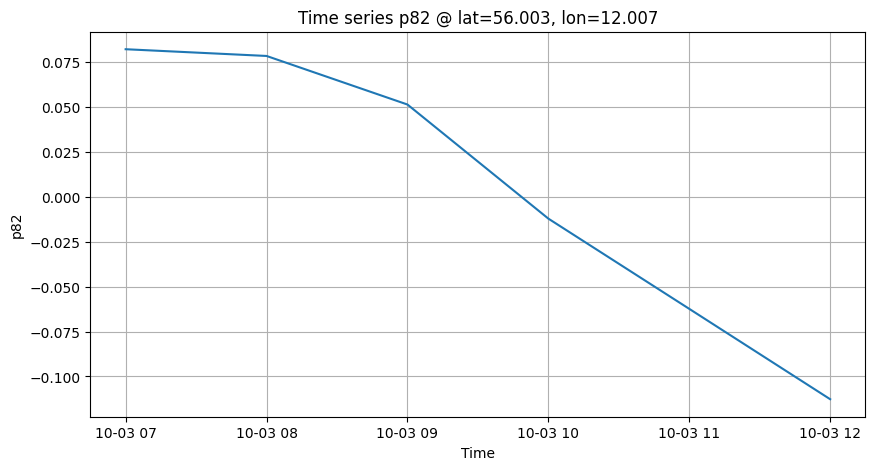

In [40]:
# scegli un punto (coordinate desiderate)
lat0, lon0 = 56.0, 12.0

p82_point = ds["p82"].sel(latitude=lat0, longitude=lon0, method="nearest")
time = ds["valid_time"].values

plt.figure(figsize=(10, 5))
plt.plot(time, p82_point.values)
plt.xlabel("Time")
plt.ylabel("p82")
plt.title(f"Time series p82 @ lat={float(p82_point.latitude.values):.3f}, lon={float(p82_point.longitude.values):.3f}")
plt.grid()
plt.show()